In [1]:
1+1

2

We can use the TypedDict class from Python's typing module.

It allows you to specify keys and their corresponding value types.

But, note that these are type hints.

They can be used by static type checkers (like mypy) or IDEs to catch potential type-related errors before the code is run.

But they are not enforced at runtime!


In [2]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name:str 
    game:Literal["cricket","badminton"]

In [3]:
def play_game(state:TypedDict):
    print("__Play Game node has been called__")
    return {"name":state["name"] + " wants to play "}

def cricket(state:TypedDict):
    print("__ Cricket node has been called __")
    return {"game":"cricket"}

def badminton(state:TypedDict):
    print("__ Badminton node has been called __")
    return {"game":"badminton"}



In [6]:
import random
def decide_play(state:TypedDictState)->Literal["cricket","badminton"]:
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

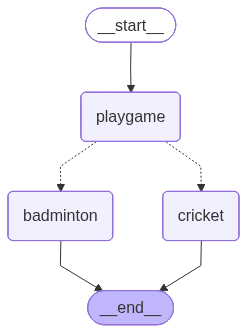

In [7]:
 
from IPython.display import Image,display 
from langgraph.graph import StateGraph,START,END 

builder = StateGraph(TypedDictState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## The flow of the Graph
builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
graph.invoke({"name":"Krish"})

__Play Game node has been called__
__ Cricket node has been called __


{'name': 'Krish wants to play ', 'game': 'cricket'}

In [9]:
graph.invoke({"name":123})

__Play Game node has been called__


TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [10]:
### DataClasses
from dataclasses import dataclass

@dataclass 
class DataClassState:
    name:str 
    game:Literal["cricket","badminton"]
    

In [11]:
def play_game(state:DataClassState):
    print("__Play Game node has been called__")
    return {"name":state.name + " wants to play "}

def cricket(state:DataClassState):
    print("__ Cricket node has been called __")
    return {"game":"cricket"}

def badminton(state:DataClassState):
    print("__ Badminton node has been called __")
    return {"game":"badminton"}



In [12]:
import random
def decide_play(state:DataClassState)->Literal["cricket","badminton"]:
    if random.random() < 0.5:
        return "cricket"
    else:
        return "badminton"

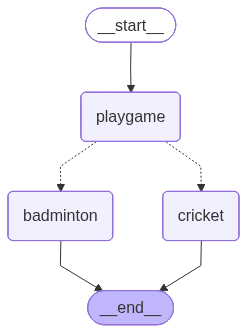

In [13]:
 
from IPython.display import Image,display 
from langgraph.graph import StateGraph,START,END 

builder = StateGraph(DataClassState)
builder.add_node("playgame",play_game)
builder.add_node("cricket",cricket)
builder.add_node("badminton",badminton)

## The flow of the Graph
builder.add_edge(START,"playgame")
builder.add_conditional_edges("playgame",decide_play)
builder.add_edge("cricket",END)
builder.add_edge("badminton",END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
graph.invoke(DataClassState(name="krish",game="cricket"))

__Play Game node has been called__
__ Cricket node has been called __


{'name': 'krish wants to play ', 'game': 'cricket'}

In [ ]:
## No runtime enforcement for the data validation problems